<a href="https://colab.research.google.com/github/afreenf2022-jpg/DataScienceInternship/blob/main/notebooks/cafe_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
#**********CAFE SALES DATASET FROM KAGGLE************

# DATA UPLOADING
#Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/dirty_cafe_sales.csv")
# Inspecting the data uploaded
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,4/27/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,6/11/2023


In [36]:
# initial data inspection
print("The shape of the data is",df.shape)
df.info()
df.describe()

The shape of the data is (10000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3,6,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [49]:
# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Rename columns for consistency
df.rename(columns={
    'transaction_id': 'transaction_id',
    'price_per_unit': 'price_per_unit',
    'total_spent': 'total_sales',
    'payment_method': 'payment_method',
    'transaction_date': 'date'
}, inplace=True)

# Clean DATE column
df['date'] = df['date'].astype(str).str.strip()
df['date'].replace(
    ['', ' ', 'nan', 'NaN', 'None', 'NULL', 'unknown', 'N/A'],
    np.nan)
df['date'] = pd.to_datetime(
    df['date'],
    errors='coerce')

# Fill missing dates
df['date'] = df['date'].ffill()

# Clean numeric columns
numeric_cols = ['quantity', 'price_per_unit', 'total_sales']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[numeric_cols] = df[numeric_cols].fillna(0)

# Standardize categorical text
invalid_values = ['error', 'Unknown', 'n/a','Nan','na', 'null', 'none', '']
text_cols = ['item', 'payment_method', 'location']
for col in text_cols:
    df[col] = (df[col].astype(str).str.strip()
              .str.lower().replace(invalid_values, 'other').str.title())

# Final check
print("The data after cleaning is")
print(df.isna().sum())


The data after cleaning is
transaction_id    0
item              0
quantity          0
price_per_unit    0
total_sales       0
payment_method    0
location          0
date              0
year              0
month             0
weekday           0
price_category    0
high_value_txn    0
dtype: int64


In [41]:
# DATA MANIPULATION
# Recalculate total sales for safety
df['total_sales'] = df['quantity'] * df['price_per_unit']

# Sales by item
sales_by_item = df.groupby('item')['total_sales'].sum().reset_index()

# Sales by payment method
sales_by_payment = df.groupby('payment_method')['total_sales'].sum().reset_index()

# Sales by location
sales_by_location = df.groupby('location')['total_sales'].sum().reset_index()

# Daily sales
daily_sales = df.groupby('date')['total_sales'].sum().reset_index()

#print(df[['quantity', 'price_per_unit', 'total_sales']].head())
print("Item sales\n",sales_by_item.head())
print("Payment\n",sales_by_payment.head())
print("Location\n",sales_by_location.head())
print("Daily sales\n",daily_sales.head())


Item sales
      item  total_sales
0    Cake       9540.0
1  Coffee       6424.0
2  Cookie       2898.0
3   Juice       9561.0
4     Nan       2651.0
Payment
    payment_method  total_sales
0            Cash      18486.0
1     Credit Card      18441.0
2  Digital Wallet      18530.0
3             Nan      20314.5
4           Other       2380.5
Location
    location  total_sales
0  In-Store      24598.0
1       Nan      26606.5
2     Other       2906.0
3  Takeaway      23868.0
4   Unknown       2500.0
Daily sales
         date  total_sales
0 2023-01-01        135.0
1 2023-01-02        170.0
2 2023-01-03        186.0
3 2023-01-04        247.5
4 2023-01-05        304.5


In [42]:
# FEATURE ENGINEERING
# Date features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.day_name()

# Price category
df['price_category'] = pd.cut(
    df['price_per_unit'],
    bins=[-0.01, 0, 3, 6, 10, np.inf],
    labels=['Free', 'Low', 'Medium', 'High', 'Premium'],
    include_lowest=True
)

df['price_category'] = df['price_category'].cat.add_categories('Unknown')
df['price_category'] = df['price_category'].fillna('Unknown')
print("Null values in price_category",df['price_category'].isna().sum())
print(df['price_category'].value_counts())


# High value transaction flag
df['high_value_txn'] = np.where(
df['total_sales'] > df['total_sales'].mean(),1,0)


Null values in price_category 0
price_category
Low        5932
Medium     3535
Free        533
High          0
Premium       0
Unknown       0
Name: count, dtype: int64


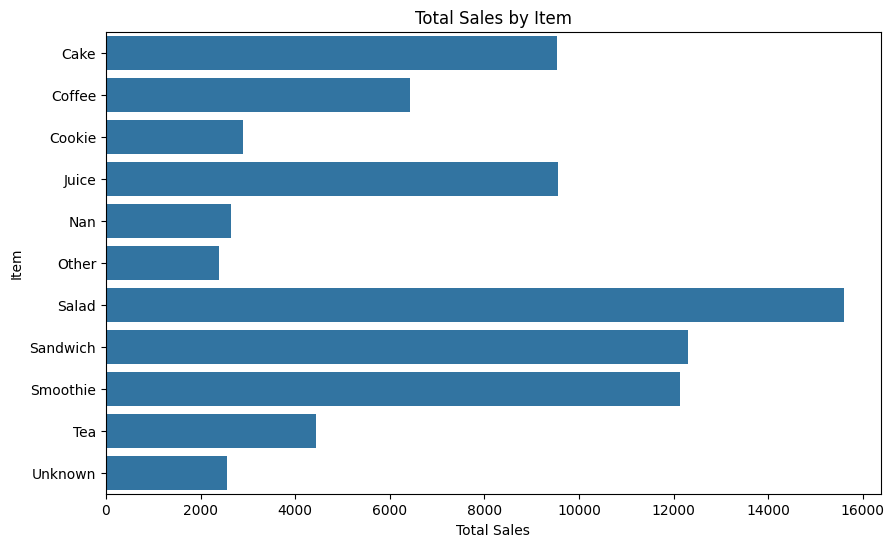

In [43]:
# DATA VISUALIZATION
# Total sales by Item
plt.figure(figsize=(10,6))
sns.barplot(data=sales_by_item, x='total_sales', y='item')
plt.title("Total Sales by Item")
plt.xlabel("Total Sales")
plt.ylabel("Item")
plt.show()


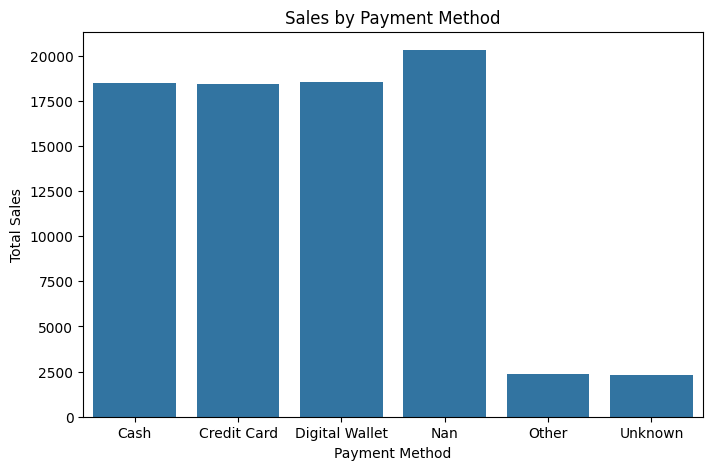

In [44]:
# Sales by payment method
plt.figure(figsize=(8,5))
sns.barplot(data=sales_by_payment, x='payment_method', y='total_sales')
plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.show()


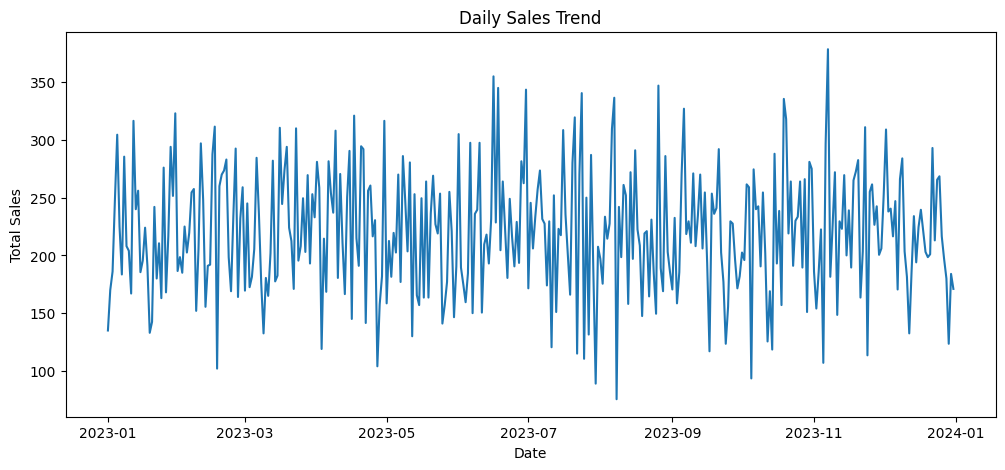

In [45]:
# Daily sales trend
plt.figure(figsize=(12,5))
plt.plot(daily_sales['date'], daily_sales['total_sales'])
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()


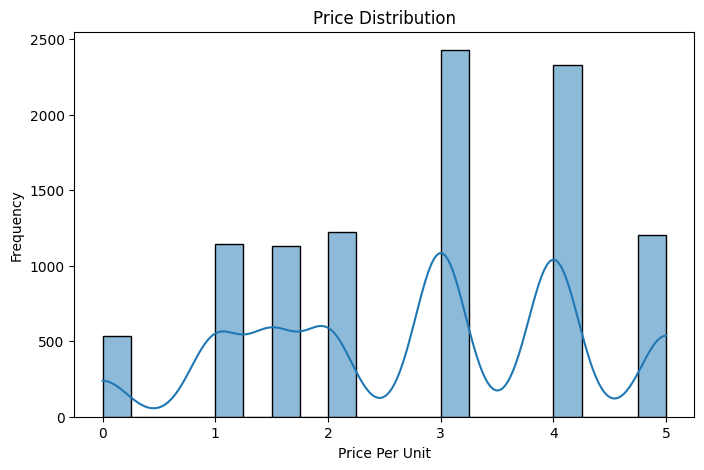

In [46]:
# Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price_per_unit'], bins=20, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price Per Unit")
plt.ylabel("Frequency")
plt.show()


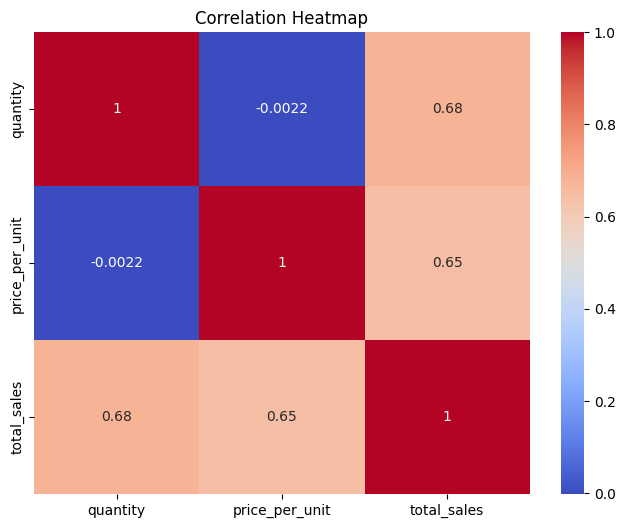

In [47]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['quantity','price_per_unit','total_sales']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
